# Analysis of Polish classical works.
The aim of this notebook is to analyze works of classical Polish authors -- our main character will be **Adam Mickiewicz**. We will describe basic statistics of the works and try to spot the differences in them to distinguish which works were written by Mickiewicz and which are written by the others.

In [1]:
import masters_of_literature.text_analysis.text_stats as stats
import masters_of_literature.text_analysis.text_authorship_prob as prob
import masters_of_literature.text_analysis.text_differences as diff
import masters_of_literature.read_input.read_text as read

In [2]:
# Here are texts written by our main author, Adam Mickiewicz
pan_tadeusz = "masters_of_literature/texts/pan_tadeusz.txt"
grazyna = "masters_of_literature/texts/grazyna.txt"
dziady_cz_3 = "masters_of_literature/texts/dziady_cz_3.txt"

# Here are textx written by other classic Polish authors, such as Zygmunt Krasiński and Bruno Schulz
moja_beatrycze = "masters_of_literature/texts/moja_beatrycze.txt"
sklepy_cynamonowe = "masters_of_literature/texts/sklepy_cynamonowe.txt"

# Here is a Polish dictionary
polish_dict = read.read_dictionary("masters_of_literature/dictionaries/pl.txt")

works = [read.read_work(pan_tadeusz),
        read.read_work(grazyna),
        read.read_work(dziady_cz_3),
        read.read_work(moja_beatrycze),
        read.read_work(sklepy_cynamonowe)]

Firstly, we will show basic some **basic statistics** about the work -- how many works (and unique works) appear in the text, what is the average length of a word etc. Then we will plot a histogram of **top ten most common words** in each work.

*Note:* Percentage of unique words is **not** calculated as ratio $\frac{\text{Unique words}}{\text{All words}}$, because if it was, it would be biased by the length of the text. The method I used was to choose 1000 random words and then from this probe calculate $\frac{\text{Unique words}}{\text{All words}}$. I've done it several times and then take the mean of all attempts.

In [3]:
import pandas as pd

works_basic_data = [stats.give_stats(work)[:4] for work in works]
works_data_frame = pd.DataFrame({"Pan Tadeusz": works_basic_data[0],
                                 "Grażyna": works_basic_data[1],
                                 "Dziady cz. 3": works_basic_data[2],
                                 "Moja Beatrycze": works_basic_data[3],
                                 "Sklepy cynamonowe": works_basic_data[4]})
works_data_frame.index = ["How_many_lines", "How_many_words", "How_many_unique_words", "Percentage of unique words", "Average length of the word"]
works_data_frame

,Pan Tadeusz,Grażyna,Dziady cz. 3,Moja Beatrycze,Sklepy cynamonowe
How_many_lines,4994,1223,3843,895,5069
How_many_words,31084,6402,19793,4180,24247
How_many_unique_words,11230,3284,6776,1959,10439
Percentage of unique words,70.9%,66.3%,67.2%,56.5%,70.6%
Average length of the word,5.266825,5.115276,4.909513,4.837799,5.840558


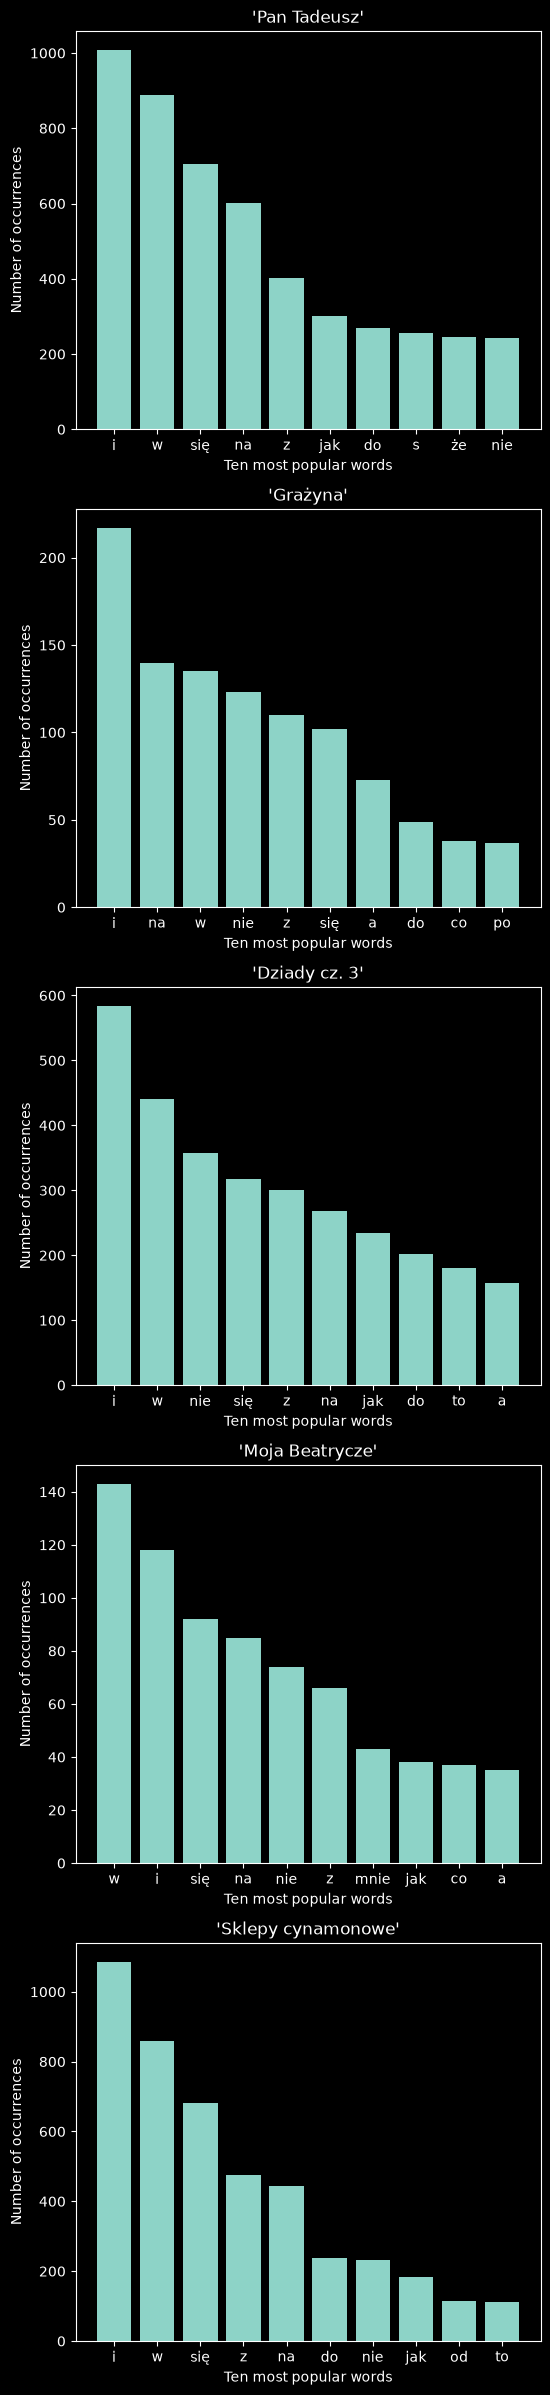

In [4]:
import matplotlib.pyplot as plt
ten_most_common_words = [stats.most_common_words(works[i], 10) for i in range(5)]

fig, axes = plt.subplots(5, 1, figsize = (6, 30))
for i in range(5):
    axes[i].bar(ten_most_common_words[i]["word"], ten_most_common_words[i]["count"])
    axes[i].set_title(f"'{works_data_frame.columns[i]}'")
    axes[i].set_xlabel("Ten most popular words")
    axes[i].set_ylabel("Number of occurrences")
plt.show()

# How many old-fashioned words can we detect?
When looking on book, which was written more than a hundred years ago, it is always good to ask, how much this text differs from modern ones and whether modern reader could have a pleasure to read the text without much inconvenience.

Now we will calculate how many words, which are not in modern dictionary, Adam Mickiewicz used in Pan Tadeusz and how many times did he used them.

In [15]:
no_words = pd.DataFrame(diff.differences(works[0], polish_dict))
no_words.head(50)

,word,count
1,tadeusz,64
2,telimena,41
3,tadeusza,36
4,gerwazy,31
5,assessor,25
6,horeszków,19
7,nakształt,15
8,litwie,14
9,zosia,14
10,zwolna,14


**Conclusion**: We see that lots of these words are names of the characters or cities or words which are written in other way than nowadays due to grammatical rules, but most of this most are understandable by a modern reader.

# How to measure what is *the probability* that two texts were written by the same author?
That is a very interesting question, especially nowadays, where thanks to NLP (Natural Language Processing) machines can interpret not only words plain statistics but also focus on semantics and deeper meaning of the text. We will restrict ourselves to statistics of the words appearing in the text. Main idea is to focus on three important features of the text:

- Diversity of vocabulary used in the text -- we will check it by choosing 1000 random words and calculate the ratio of $\frac{\text{unique words}}{1000} * 100$% several times and then take a mean of the results.

- Similarity of using uncommon words -- we will take a 100 most common words used in the text, which are not **stopwords**, which are words common used in natural language like prepositions, conjunctions etc. and see how many of them appears in both works. It may be a little biased, because in each book main characters have different names and main topic is different. On the other hand, the author may have favourite adjectives to describe the nature or he permanently uses one synonym for the verb 'to walk' and we will be able to notice that.

- Length of the words -- we will look on the histogram of the length of the words and try to see some patterns and then compare the averages of the words used in both texts.

Finally, using my heuristics we will calculate our probability as a weighted sum:

$$
\mathbb{P}(\text{two works were written by the same author}) = 0.4 * \text{coef}_{\text{diversity}} + 0.4 * \text{coef}_{\text{similarity}} + 0.2 * \text{coef}_{\text{length of words}}
$$

# Examples
Let's look on some example.

Let's compare two of the most famous work of our author **"Pan Tadeusz"** and **"Dziady cz.3"** by three metrics mentioned above

In [6]:
print(f"Percentage of unique words in 'Pan Tadeusz': {works_data_frame.iloc[3, 0]}")
print(f"Percentage of unique words in 'Dziady cz. 3': {works_data_frame.iloc[3, 2]}")
print(f"Diversity coefficient is equal to: {prob.diversity_comparison(works[0], works[2])}")

Percentage of unique words in 'Pan Tadeusz': 70.9%
Percentage of unique words in 'Dziady cz. 3': 67.2%
Diversity coefficient is equal to: 85.0


In [7]:
print(f"Similarity coefficient is equal to: {prob.similarity_comparison(works[0], works[2])}")
print("Most common unusual words")
diff.give_characteristic_words(works[0], works[2])

Similarity coefficient is equal to: 85.0
Most common unusual words


,word,first_work,second_work
1,oczy,39,21
2,potem,38,22
3,choć,40,15
4,domu,40,12
5,raz,34,14
6,strony,27,16
7,ziemi,19,23
8,cóż,15,26
9,siebie,22,19
10,długo,20,18


Average length coefficient is equal to: 64.26880879566514


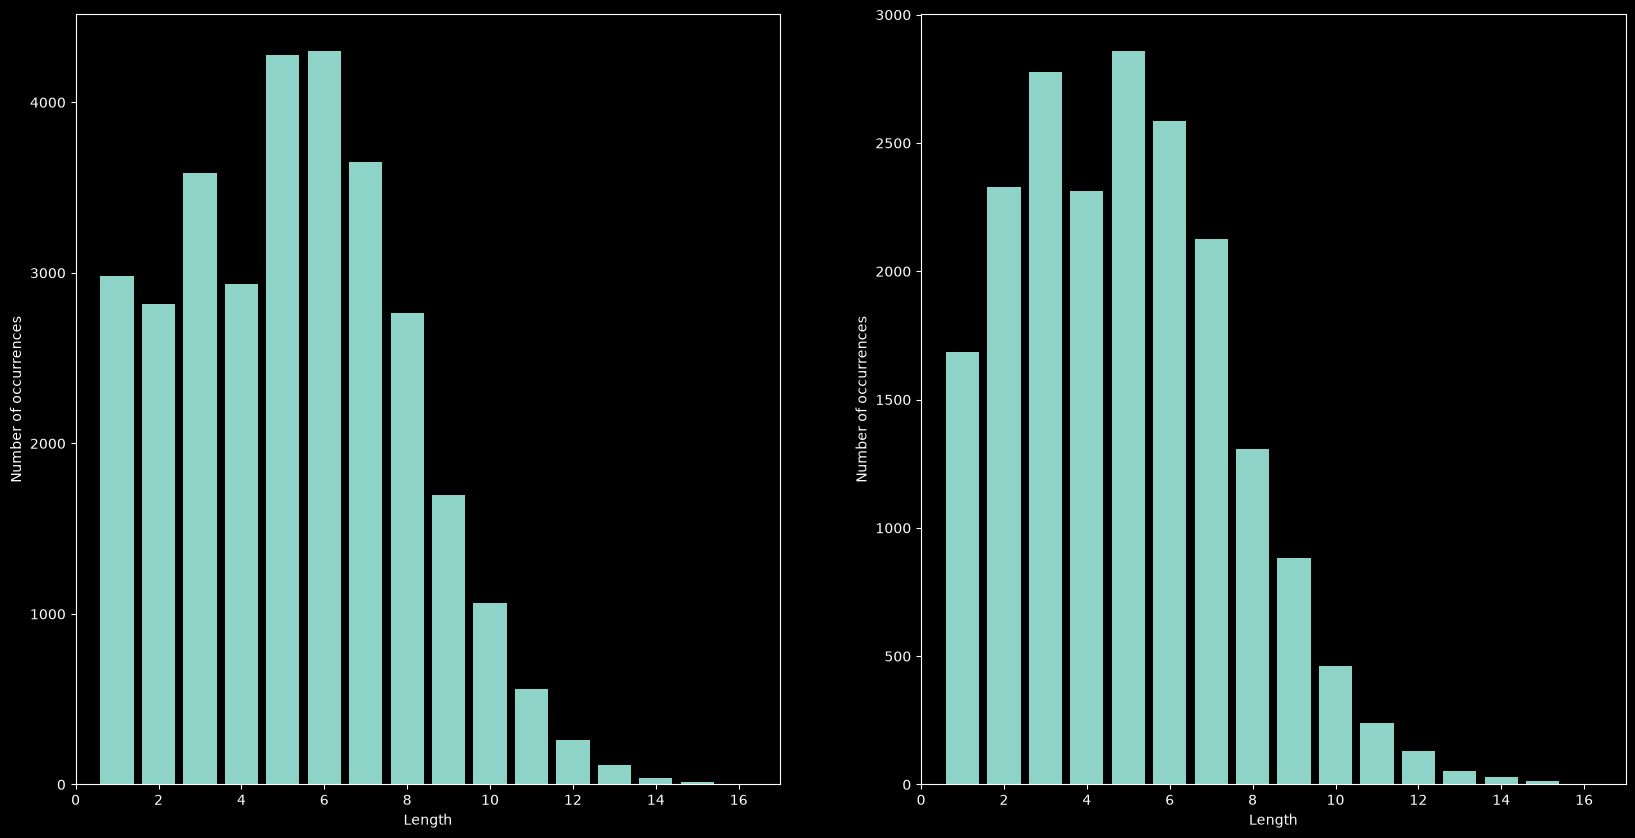

In [8]:
print(f"Average length coefficient is equal to: {prob.average_len_of_word_comparison(works[0], works[2])}")
data = prob.print_average_len_of_word_comparison(works[0], works[2])

fig, axes = plt.subplots(1, 2, figsize = (20, 10))

for i in range(2):
    axes[i].bar(data[i].keys(), data[i].values())
    axes[i].set_xlabel("Length")
    axes[i].set_ylabel("Number of occurrences")
    axes[i].set_xlim(0, 17)

plt.show()

In [9]:
print(f"Finally, the probability that works were written by the same author is equal to {prob.probability_function(works[0], works[2])}")

Finally, the probability that works were written by the same author is equal to 80.05%


Now, let's check how our function works in the case of works written by two different authors -- **"Grażyna"** by Adam Mickiewicz and **"Moja Beatrycze"** by Zygmunt Krasiński"

In [10]:
print(f"Percentage of unique words in 'Grażyna': {works_data_frame.iloc[3, 1]}")
print(f"Percentage of unique words in 'Moja Beatrycze': {works_data_frame.iloc[3, 3]}")
print(f"Diversity coefficient is equal to: {prob.diversity_comparison(works[1], works[3])}")

Percentage of unique words in 'Grażyna': 66.3%
Percentage of unique words in 'Moja Beatrycze': 56.5%
Diversity coefficient is equal to: 52.0


In [11]:
print(f"Similarity coefficient is equal to: {prob.similarity_comparison(works[1], works[3])}")
print("Most common unusual words")
diff.give_characteristic_words(works[1], works[3])

Similarity coefficient is equal to: 70.0
Most common unusual words


,word,first_work,second_work
1,choć,8,8
2,ziemi,5,11
3,serca,5,10
4,serce,5,10
5,siebie,7,7
6,głos,9,5
7,czas,5,9
8,noc,8,5
9,jutro,8,4
10,myśli,8,4


Average length coefficient is equal to: 64.26880879566514


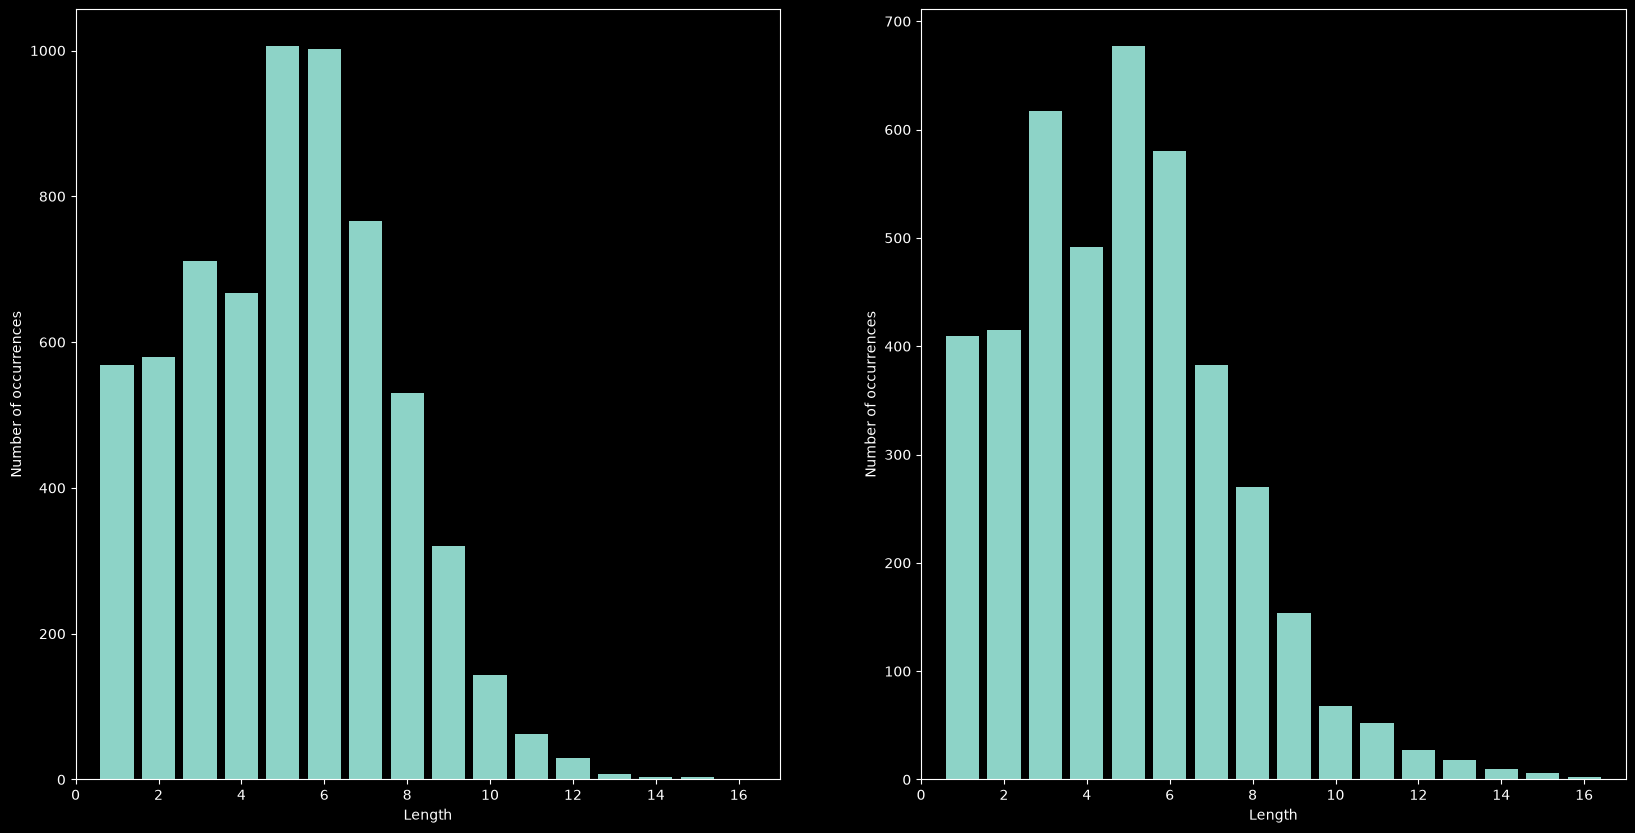

In [12]:
print(f"Average length coefficient is equal to: {prob.average_len_of_word_comparison(works[0], works[2])}")
data = prob.print_average_len_of_word_comparison(works[1], works[3])

fig, axes = plt.subplots(1, 2, figsize = (20, 10))

for i in range(2):
    axes[i].bar(data[i].keys(), data[i].values())
    axes[i].set_xlabel("Length")
    axes[i].set_ylabel("Number of occurrences")
    axes[i].set_xlim(0, 17)

plt.show()

In [13]:
print(f"The probability that works were written by the same author is equal to {prob.probability_function(works[1], works[3])}")

The probability that works were written by the same author is equal to 62.85%


Summing up, we will create the table comparing each of the five works, presented at the beginning of this notebook

In [14]:
import numpy as np
n = 5
prob_data = np.empty((n, n), dtype=object)

for i in range(n):
    for j in range(i, n):
        prob_data[i, j] = prob.probability_function(works[i], works[j])

for i in range(n):
    for j in range(i + 1, n):
        prob_data[j, i] = prob_data[i, j]

prob_data_frame = pd.DataFrame(prob_data)
prob_data_frame.columns = ["Pan Tadeusz", "Grażyna", "Dziady cz. 3", "Moja Beatrycze", "Sklepy cynamonowe"]
prob_data_frame.index = prob_data_frame.columns
prob_data_frame

,Pan Tadeusz,Grażyna,Dziady cz. 3,Moja Beatrycze,Sklepy cynamonowe
Pan Tadeusz,99.2%,89.77%,80.05%,49.82%,80.13%
Grażyna,89.77%,98.4%,87.88%,62.85%,62.29%
Dziady cz. 3,80.05%,87.88%,100.0%,73.77%,58.18%
Moja Beatrycze,49.82%,62.85%,73.77%,98.4%,38.8%
Sklepy cynamonowe,80.13%,62.29%,58.18%,38.8%,100.0%


# Conclusions:
- Adam Mickiewicz uses a wide variety of words in his texts.
- He used mostly neither short, neither long words.
- His language does not differ as much as I expected. The differences in the most used words, which is not in current polish dictionary comes from other grammatical rules. At the same time, they are understandable for a modern reader.
- He has his own style of writing, which we are able to capture by our probability function